# Module 1 - Revisiting Basics of Keplerian Motion

...or introduction to orbital mechanics if this is your first rodeo ;)

This module revisits the fundamentals of unperturbed Keplerian spacecraft motion. The material is presented as a review and therefore moves quickly, with the assumption that the basic concepts of particle kinematics and orbital mechanics have been encountered before.

The first part of the module returns to particle kinematics and the description of motion using position, velocity, and acceleration vectors. This provides the mathematical foundation needed to describe spacecraft motion consistently before introducing the orbital dynamics.

The remainder of the module reviews the classical two-body problem, beginning with conic sections and progressing to Kepler's equation and the classical orbital elements. Together, these concepts provide the baseline description of ideal spacecraft motion before perturbations and relative-motion effects are introduced later in the course.

**<ins>Learning Objectives</ins>**

- Review the fundamental relationships used in particle kinematics.
- Describe Keplerian orbits using conic sections.
- Apply Kepler's equation to determine spacecraft position as a function of time.
- Describe an orbit using the classical orbital elements.
- Establish the two-body Keplerian model that will be used as the reference for later relative-motion analysis.

**<ins>Content</ins>**
- Particle kinematics fundamentals
- Conic sections and Keplerian orbits
- Kepler's equation and orbital time propagation
- Classical orbital elements

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.1 - Fundamentals of Particle Kinematics

## 1.1.1 - Vectors, Reference Frames, and Coordinate Representation

Before describing motion, we first need to be precise about **what is being measured** and **relative to what it is being measured**.

A **scalar** is a physical quantity that can be completely described by a single numerical value and its associated units. Scalars have magnitude but no direction. Examples include mass, temperature, time, and distance.

A **vector**, on the other hand, contains both magnitude and direction. Position, velocity, acceleration, and force are all vector quantities.

Consider the statement:

> An object is located $5\,\text{m}$ away.

This statement is incomplete if we want to describe the object's position. We must also ask:

- $5\,\text{m}$ away from **what point**?
- In **what direction**?

The reference point defines the **origin** from which the position is measured. Together with a set of basis directions, this defines a **reference frame**.

**<ins>Reference Frames and Coordinate Representation</ins>**

Consider a reference frame $N$ with three orthogonal basis vectors

$$
\mathcal{N} =
\left\{
\hat{\mathbf n}_1,
\hat{\mathbf n}_2,
\hat{\mathbf n}_3
\right\}.
$$

A physical vector $\mathbf r$ can be constructed from these basis vectors as

$$
\mathbf r = r_1\hat{\mathbf n}_1 + r_2\hat{\mathbf n}_2 + r_3\hat{\mathbf n}_3.
$$

The scalars $r_1$, $r_2$, and $r_3$ tell us how much of $\mathbf r$ lies along each basis direction. These values are called the **components** of the vector in frame $N$.

We can collect these components into a column vector,

$$
[\mathbf r]_N =
\begin{bmatrix}
r_1\\
r_2\\
r_3
\end{bmatrix}.
$$

This is the **coordinate representation** of $\mathbf r$ in frame $N$.

It is important to distinguish between the two:

$$
\boxed{
\mathbf r
\quad\text{is the geometric vector}
}
$$

while

$$
\boxed{
[\mathbf r]_N
\quad\text{is its numerical representation in frame }N
}
$$

If another reference frame $B$ is used, the same physical vector may have a different coordinate representation,

$$
[\mathbf r]_B \neq [\mathbf r]_N,
$$

even though $\mathbf r$ itself has not changed.

In numerical work, we usually store and manipulate these **vector components** and transform them from one frame to another using a **Direction Cosine Matrices (DCMs)**,

$$
[\mathbf r]_B = [BN] [\mathbf r]_N
$$

where $[BN]$ is the DCM decribing the orientation of the $B$-frame to the $N$-frame and provides a means to map a vector in $N$-frame to the $B$-frame. Please refer to the course notes in the first specialization, specifically the first course, where an extensive treatment is done to describe DCMs and the equivalent attitude representations to decribe orientation and frame conversions.

**<ins>Inertial Reference Frames</ins>**

Newton's laws take their simplest form when motion is described relative to an **inertial reference frame**.

An inertial frame is a frame whose origin is not accelerating and whose axes are not rotating relative to inertial space. A frame may translate at constant velocity and still be inertial.

In such a frame, the acceleration obtained by differentiating the position vector twice corresponds directly to the acceleration used in Newton's second law,

$$
\mathbf F = m\ddot{\mathbf r}.
$$

If the reference frame itself accelerates or rotates, additional kinematic terms appear. Understanding how vector derivatives change between different reference frames will therefore become important when describing spacecraft motion.

In [2]:
# ---------------------------------------------------------------------------------------
# Vector and frame notation
#
# In numerical code, explicitly include the reference frame in the variable name:
#
#     <vector>_<frame> = np.array([...])
#
# Example:
#
#     r_N
#
# means:
#     "the components of the geometric vector r expressed in reference frame N."
#
# For direction cosine matrices:
#
#     C_BN
#
# maps vector components from frame N into frame B:
#
#     r_B = C_BN @ r_N
#
# Unless explicitly stated otherwise, coordinate transformations in this notebook
# are PASSIVE:
#
#     - The physical vector does not rotate.
#     - The reference frame / basis changes.
#     - Only the coordinate representation changes.
#
# Active rotations will be explicitly identified as rotations of the geometric vector.
# ---------------------------------------------------------------------------------------

# Vector expressed in reference frame N
r_N = np.array([4.0, 3.0])

# Frame B is rotated counter-clockwise relative to frame N
theta = np.deg2rad(35.0)

c = np.cos(theta)
s = np.sin(theta)

# Passive transformation: N-components -> B-components
C_BN = np.array([
    [ c,  s],
    [-s,  c]
])

r_B = C_BN @ r_N

# Active rotation: rotate the physical vector by +theta while keeping frame N fixed
R_theta = np.array([
    [c, -s],
    [s,  c]
])

r_rotated_N = R_theta @ r_N

print(f"Vector components in frame N: {r_N}")
print(f"Vector components in frame B: {r_B}")
print(f"Actively rotated vector in frame N: {r_rotated_N}")

print(f"\nMagnitude in frame N: {np.linalg.norm(r_N):.3f}")
print(f"Magnitude in frame B: {np.linalg.norm(r_B):.3f}")
print(f"Magnitude after active rotation: {np.linalg.norm(r_rotated_N):.3f}")

Vector components in frame N: [4. 3.]
Vector components in frame B: [4.99733749 0.16315039]
Actively rotated vector in frame N: [1.55587887 4.75176188]

Magnitude in frame N: 5.000
Magnitude in frame B: 5.000
Magnitude after active rotation: 5.000


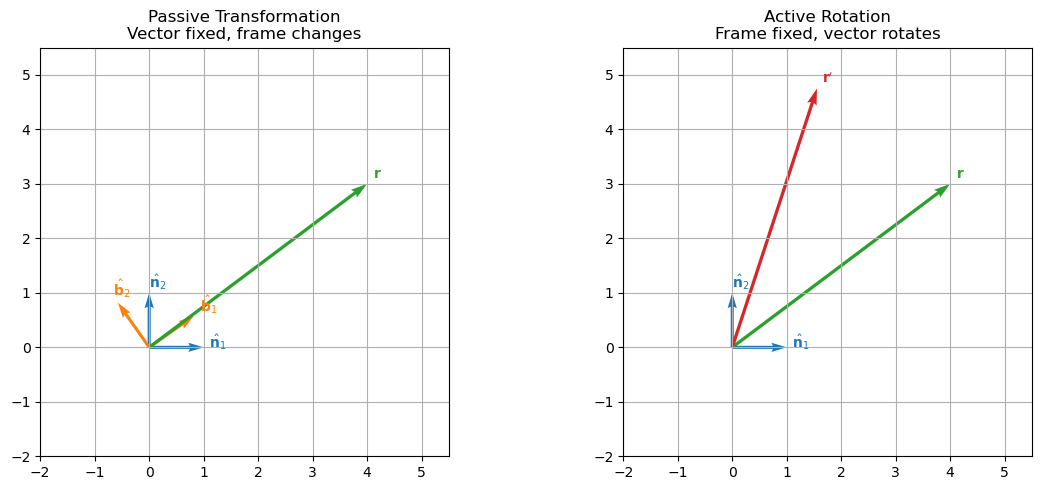

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Basis vectors of frame N
n1_N = np.array([1.0, 0.0])
n2_N = np.array([0.0, 1.0])

# Basis vectors of frame B expressed in frame N
b1_N = np.array([ c, s])
b2_N = np.array([-s, c])

# Passive transformation
ax = axes[0]

ax.quiver(
    0, 0, *n1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)
ax.quiver(
    0, 0, *n2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)

ax.quiver(
    0, 0, *b1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:orange"
)
ax.quiver(
    0, 0, *b2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:orange"
)

ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:green"
)

ax.text(1.1, 0.0, r"$\hat{\mathbf{n}}_1$", color="tab:blue")
ax.text(0.0, 1.1, r"$\hat{\mathbf{n}}_2$", color="tab:blue")
ax.text(*(1.15 * b1_N), r"$\hat{\mathbf{b}}_1$", color="tab:orange")
ax.text(*(1.15 * b2_N), r"$\hat{\mathbf{b}}_2$", color="tab:orange")
ax.text(
    r_N[0] + 0.1,
    r_N[1] + 0.1,
    r"$\mathbf{r}$",
    color="tab:green"
)

ax.set_title("Passive Transformation\nVector fixed, frame changes")
ax.set_xlim(-2, 5.5)
ax.set_ylim(-2, 5.5)
ax.set_aspect("equal")
ax.grid()


# Active rotation
ax = axes[1]

ax.quiver(
    0, 0, *n1_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)
ax.quiver(
    0, 0, *n2_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue"
)

ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:green"
)

ax.quiver(
    0, 0, *r_rotated_N,
    angles="xy", scale_units="xy", scale=1,
    width=0.008,
    color="tab:red"
)

ax.text(1.1, 0.0, r"$\hat{\mathbf{n}}_1$", color="tab:blue")
ax.text(0.0, 1.1, r"$\hat{\mathbf{n}}_2$", color="tab:blue")

ax.text(
    r_N[0] + 0.1,
    r_N[1] + 0.1,
    r"$\mathbf{r}$",
    color="tab:green"
)

ax.text(
    r_rotated_N[0] + 0.1,
    r_rotated_N[1] + 0.1,
    r"$\mathbf{r}^{\prime}$",
    color="tab:red"
)

ax.set_title("Active Rotation\nFrame fixed, vector rotates")
ax.set_xlim(-2, 5.5)
ax.set_ylim(-2, 5.5)
ax.set_aspect("equal")
ax.grid()

plt.tight_layout()
plt.show()

**<ins>Intuitive Summary</ins>**

A vector is a physical geometric quantity. What changes from one reference frame to another is not the vector itself, but the **numbers used to describe it**.

The reference frame provides the origin and basis directions. Once a frame is chosen, the vector can be written through its components in that frame,

$$
[\mathbf r]_N.
$$

If we change the frame from $N$ to $B$ while keeping the physical vector fixed, we perform a **passive transformation**,

$$
[\mathbf r]_B = [C_{BN}][\mathbf r]_N.
$$

The vector has not moved. We have simply changed the coordinate system used to describe it.

An **active transformation** does the opposite. The reference frame stays fixed while the physical vector itself is rotated,

$$
[\mathbf r']_N = [R(\theta)][\mathbf r]_N.
$$

The easiest way to remember the difference is therefore

$$
\boxed{
\text{Passive: move the frame, keep the vector fixed}
}
$$

$$
\boxed{
\text{Active: keep the frame fixed, move the vector}
}
$$

For the same relative rotation, these operations act in opposite directions. Therefore,

$$
[C_{BN}] = [R(\theta)]^{-1} = [R(\theta)]^T.
$$

The transpose appears because rotation matrices are orthogonal, so reversing a rotation is equivalent to transposing its matrix.

Throughout these notes, transformations between reference frames will be treated as **passive transformations unless explicitly stated otherwise**.

With the ideas of vectors, frames, and coordinate representation established, the next question is:

> What happens when these vectors change with time?

This leads naturally to position, velocity, and acceleration.

## 1.1.2 - Position, Velocity and Acceleration

A reference frame allows us to describe **where** an object is. Kinematics extends this idea by asking how that position changes with time.

**<ins>Position</ins>**

Consider a particle $P$ whose position relative to the origin of reference frame $N$ is described by the position vector

$$
\mathbf r = x\hat{\mathbf n}_1 + y\hat{\mathbf n}_2 + z\hat{\mathbf n}_3.
$$

Its coordinate representation in frame $N$ is therefore

$$
[\mathbf r]_N =
\begin{bmatrix}
x\\
y\\
z
\end{bmatrix}.
$$

If the particle moves, the components $x$, $y$, and $z$ become functions of time,

$$
\mathbf r(t) = x(t)\hat{\mathbf n}_1 + y(t)\hat{\mathbf n}_2 + z(t)\hat{\mathbf n}_3.
$$

The position vector therefore answers the first kinematic question:

> Where is the particle relative to the chosen origin?

**<ins>Velocity</ins>**

Velocity describes how the position vector changes with time.

The velocity of $P$ observed from frame $N$ is defined as

$$
\mathbf v = {}^{N}\frac{d\mathbf r}{dt}.
$$

The superscript $N$ is important. It identifies the reference frame with respect to which the derivative is being taken.

If frame $N$ is non-rotating, its basis vectors do not change direction with time. Therefore,

$$
{}^{N}\frac{d\hat{\mathbf n}_i}{dt}=0,
$$

and the derivative reduces to

$$
\mathbf v = \dot{x}\hat{\mathbf n}_1 + \dot{y}\hat{\mathbf n}_2 + \dot{z}\hat{\mathbf n}_3.
$$

Hence,

$$
[\mathbf v]_N =
\begin{bmatrix}
\dot{x}\\
\dot{y}\\
\dot{z}
\end{bmatrix}.
$$

Velocity therefore describes both the **speed** and **direction of motion** of the particle. Geometrically, the velocity vector is tangent to the trajectory followed by the particle.

**<ins>Acceleration</ins>**

Acceleration describes how the velocity vector changes with time,

$$
\mathbf a = {}^{N}\frac{d\mathbf v}{dt} = {}^{N}\frac{d^2\mathbf r}{dt^2}.
$$

For a non-rotating frame $N$,

$$
\mathbf a = \ddot{x}\hat{\mathbf n}_1 + \ddot{y}\hat{\mathbf n}_2 + \ddot{z}\hat{\mathbf n}_3,
$$

with coordinate representation

$$
[\mathbf a]_N =
\begin{bmatrix}
\ddot{x}\\
\ddot{y}\\
\ddot{z}
\end{bmatrix}.
$$

Acceleration does not necessarily mean that the particle is speeding up or slowing down. Because velocity is a vector, acceleration may result from a change in

- the magnitude of the velocity,
- the direction of the velocity,
- or both.

A particle travelling at constant speed along a curved path therefore still experiences acceleration because the direction of its velocity is continuously changing.

The fundamental kinematic relationship can therefore be summarized as

$$
\boxed{
\mathbf r
\xrightarrow{\ d/dt\ }
\mathbf v
\xrightarrow{\ d/dt\ }
\mathbf a
}
$$

However, there is an important condition hidden inside these derivatives.

The expressions above were simple because the basis vectors of frame $N$ were assumed not to rotate. If the reference frame itself rotates, then

$$
{}^{N}\frac{d\hat{\mathbf b}_i}{dt} \neq 0,
$$

and differentiating only the scalar components of a vector is no longer sufficient.

This raises the next important question:

> How does the derivative of a vector change when the reference frame itself is moving or rotating?

In [4]:
# ---------------------------------------------------------------------------------------
# Position, velocity, and acceleration
#
# Consider a particle moving along a circular path:
#
#     r(t) = [R cos(wt), R sin(wt)]
#
# The velocity is the time derivative of position:
#
#     v(t) = dr/dt
#
# and the acceleration is the time derivative of velocity:
#
#     a(t) = dv/dt
#
# Even though the speed is constant, the velocity direction changes continuously,
# producing a non-zero acceleration directed toward the centre of the circle.
# ---------------------------------------------------------------------------------------

R = 4.0
w = 0.8
t = 1.0

# Position, velocity, and acceleration expressed in frame N
r_N = np.array([
    R * np.cos(w * t),
    R * np.sin(w * t)
])

v_N = np.array([
    -R * w * np.sin(w * t),
     R * w * np.cos(w * t)
])

a_N = np.array([
    -R * w**2 * np.cos(w * t),
    -R * w**2 * np.sin(w * t)
])

print(f"Time, t:           {t}")
print(f"Position, r_N:     {r_N}")
print(f"Velocity, v_N:     {v_N}")
print(f"Acceleration, a_N: {a_N}")

print(f"\nSpeed:            {np.linalg.norm(v_N):.3f}")
print(f"Acceleration:     {np.linalg.norm(a_N):.3f}")

Time, t:           1.0
Position, r_N:     [2.78682684 2.86942436]
Velocity, v_N:     [-2.29553949  2.22946147]
Acceleration, a_N: [-1.78356918 -1.83643159]

Speed:            3.200
Acceleration:     2.560


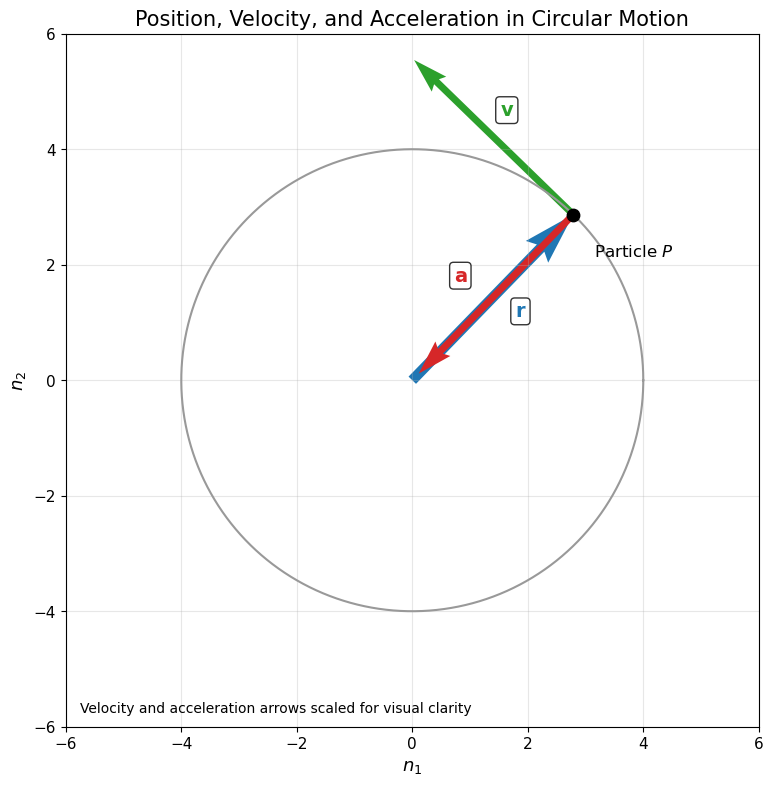

In [5]:
# Circular trajectory
t_plot = np.linspace(0.0, 2.0 * np.pi / w, 400)

x = R * np.cos(w * t_plot)
y = R * np.sin(w * t_plot)

# Visual scaling only, so the arrows are easy to compare
v_scale = 1.2
a_scale = 1.5

v_plot_N = v_scale * v_N
a_plot_N = a_scale * a_N

fig, ax = plt.subplots(figsize=(9, 9))

ax.plot(x, y, color="0.6", linewidth=1.5, label="Trajectory")

# Position vector
ax.quiver(
    0, 0, *r_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:blue",
    width=0.015
)

# Velocity vector
ax.quiver(
    r_N[0], r_N[1], *v_plot_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:green",
    width=0.010
)

# Acceleration vector
ax.quiver(
    r_N[0], r_N[1], *a_plot_N,
    angles="xy", scale_units="xy", scale=1,
    color="tab:red",
    width=0.010
)

# Particle
ax.scatter(
    *r_N,
    s=80,
    color="black",
    zorder=5,
    label="Particle"
)

# Labels
ax.annotate(
    r"$\mathbf{r}$",
    xy=0.55 * r_N,
    xytext=(10, -20),
    textcoords="offset points",
    fontsize=14,
    color="tab:blue",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
)

ax.annotate(
    r"$\mathbf{v}$",
    xy=r_N + 0.55 * v_plot_N,
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=14,
    color="tab:green",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
)

ax.annotate(
    r"$\mathbf{a}$",
    xy=r_N + 0.55 * a_plot_N,
    xytext=(-25, 15),
    textcoords="offset points",
    fontsize=14,
    color="tab:red",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
)

ax.annotate(
    "Particle $P$",
    xy=r_N,
    xytext=(15, -30),
    textcoords="offset points",
    fontsize=12
)

ax.set_title(
    "Position, Velocity, and Acceleration in Circular Motion",
    fontsize=15
)

ax.set_xlabel(r"$n_1$", fontsize=13)
ax.set_ylabel(r"$n_2$", fontsize=13)

ax.tick_params(labelsize=11)

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

ax.text(
    0.02, 0.02,
    "Velocity and acceleration arrows scaled for visual clarity",
    transform=ax.transAxes,
    fontsize=10
)

plt.show()

## 1.1.3 - Newton's Laws and Inertial Frames

In the previous section, acceleration was introduced as the time rate of change of velocity,

$$
\mathbf a = {}^{N}\frac{d\mathbf v}{dt} = {}^{N}\frac{d^2\mathbf r}{dt^2}.
$$

Kinematics describes how a particle moves. **Dynamics** introduces the physical causes of that motion.

The connection between the two is provided by Newton's laws.

**<ins>Newton's First Law</ins>**

Newton's first law states that a particle remains at rest or continues moving with constant velocity unless acted upon by a net external force.

Therefore, if

$$
\sum \mathbf F = \mathbf 0,
$$

then

$$
\mathbf v = \text{constant}.
$$

This statement also gives us a practical definition of an **inertial reference frame**: a frame in which a force-free particle moves with constant velocity.

An inertial frame therefore has no translational acceleration and does not rotate relative to inertial space. It may, however, translate at constant velocity.

**<ins>Newton's Second Law</ins>**

Newton's second law relates the net external force acting on a particle to its acceleration.

For a particle of constant mass,

$$
\sum \mathbf F = m\mathbf a.
$$

Using the kinematic definition of acceleration,

$$
\boxed{
\sum \mathbf F = m\,{}^{N}\frac{d^2\mathbf r}{dt^2}
}
$$

where $N$ must be an inertial reference frame.

This condition is important. The familiar expression

$$
\sum \mathbf F = m\ddot{\mathbf r}
$$

does not mean that $\mathbf r$ may be differentiated with respect to any arbitrary observer. The derivatives must represent the acceleration measured relative to an inertial frame.

If the observing frame itself accelerates or rotates, the measured acceleration contains additional terms associated with the motion of the frame.

**<ins>Newton's Third Law</ins>**

Newton's third law states that forces between two interacting bodies occur in equal and opposite pairs.

If body $A$ exerts a force on body $B$,

$$
\mathbf F_{A\rightarrow B},
$$

then body $B$ exerts

$$
\mathbf F_{B\rightarrow A} = -\mathbf F_{A\rightarrow B}.
$$

These forces have equal magnitude and opposite direction, but act on different bodies.

This becomes particularly useful when considering gravitational interactions between spacecraft and celestial bodies.

**<ins>Inertial Frames in Orbital Mechanics</ins>**

For spacecraft motion about Earth, an Earth-Centered Inertial (ECI) frame is commonly used. Its origin is placed at the centre of the Earth, while its coordinate axes are treated as non-rotating.

Strictly speaking, the Earth's centre is not perfectly inertial because it accelerates as Earth orbits the Sun. However, for many Earth-orbit problems this acceleration can be neglected over the time scale of interest, allowing the Earth-centred frame to be treated as approximately inertial.

This is an example of an important modelling principle:

> A reference frame does not need to be perfectly inertial in an absolute sense. It needs to be sufficiently inertial for the dynamics being modelled.

**<ins>Why This Matters for Relative Motion</ins>**

For a single spacecraft, Newton's second law can be applied directly to its position relative to an inertial origin,

$$
m\ddot{\mathbf r} = \sum \mathbf F.
$$

Relative spacecraft motion is more subtle.

Suppose two spacecraft have inertial position vectors

$$
\mathbf r_1
\qquad\text{and}\qquad
\mathbf r_2.
$$

Their relative position may be defined as

$$
\boldsymbol\rho = \mathbf r_2-\mathbf r_1.
$$

Although $\boldsymbol\rho$ describes the position of one spacecraft relative to another, it is not automatically a position vector measured from an inertial origin.

If the relative motion is expressed using a rotating frame attached to one spacecraft, then simply writing

$$
m\ddot{\boldsymbol\rho} = \mathbf F
$$

would generally be incorrect.

We first need to understand how derivatives of vectors observed in one reference frame are related to derivatives observed in another.

This leads to the **transport theorem**, which provides the mathematical connection between vector derivatives taken in different reference frames.

## 1.1.4 - Rotating Frames and Transport Theorem

So far, vector differentiation has been straightforward because the observing frame has been assumed to be non-rotating.

For a vector expressed in frame $B$,

$$
\mathbf r = r_1\hat{\mathbf b}_1 + r_2\hat{\mathbf b}_2 + r_3\hat{\mathbf b}_3,
$$

the vector may change for two different reasons:

1. its scalar components $r_1$, $r_2$, and $r_3$ may change with time, or
2. the basis vectors $\hat{\mathbf b}_1$, $\hat{\mathbf b}_2$, and $\hat{\mathbf b}_3$ may themselves rotate.

This distinction is what makes vector differentiation in rotating reference frames different from ordinary component-wise differentiation.

**<ins>Angular Velocity of a Reference Frame</ins>**

Let frame $B$ rotate relative to frame $N$ with angular velocity

$$
\boldsymbol\omega_{B/N}.
$$

This notation describes the angular velocity of frame $B$ relative to frame $N$.

If a basis vector $\hat{\mathbf b}_i$ is fixed in frame $B$, then an observer attached to $B$ sees no change in that basis vector,

$$
{}^{B}\frac{d\hat{\mathbf b}_i}{dt} = 0.
$$

However, an observer in frame $N$ sees the basis vector rotating. Its derivative is therefore

$$
{}^{N}\frac{d\hat{\mathbf b}_i}{dt} = \boldsymbol\omega_{B/N} \times \hat{\mathbf b}_i.
$$

The cross product appears because the instantaneous change of a rotating vector is perpendicular to both the vector itself and the axis of rotation.

**<ins>Deriving the Transport Theorem</ins>**

Consider again

$$
\mathbf r = r_1\hat{\mathbf b}_1 + r_2\hat{\mathbf b}_2 + r_3\hat{\mathbf b}_3.
$$

Differentiating with respect to frame $N$ gives

$$
{}^{N}\frac{d\mathbf r}{dt} = \sum_{i=1}^{3} \left( \dot r_i\hat{\mathbf b}_i + r_i\,{}^{N}\frac{d\hat{\mathbf b}_i}{dt} \right).
$$

The first term represents the change in the vector components as observed in frame $B$,

$$
{}^{B}\frac{d\mathbf r}{dt} = \sum_{i=1}^{3} \dot r_i\hat{\mathbf b}_i.
$$

Using

$$
{}^{N}\frac{d\hat{\mathbf b}_i}{dt} = \boldsymbol\omega_{B/N} \times \hat{\mathbf b}_i,
$$

the second term becomes

$$
\boldsymbol\omega_{B/N} \times \mathbf r.
$$

Therefore,

$$
\boxed{
{}^{N}\frac{d\mathbf r}{dt} = {}^{B}\frac{d\mathbf r}{dt} + \boldsymbol\omega_{B/N} \times \mathbf r
}
$$

This relationship is known as the **transport theorem**.

It tells us that the rate of change of a vector observed from frame $N$ consists of two contributions:

$$
\boxed{
\text{change observed in }B + \text{change caused by rotation of }B
}
$$

A useful limiting case occurs when $\mathbf r$ is completely fixed in frame $B$,

$$
{}^{B}\frac{d\mathbf r}{dt}=0.
$$

An observer in frame $N$ still sees the vector changing because frame $B$ itself is rotating,

$$
{}^{N}\frac{d\mathbf r}{dt} = \boldsymbol\omega_{B/N} \times \mathbf r.
$$

This is the same idea encountered earlier with passive transformations, except the reference frame is now changing continuously with time.

**<ins>Acceleration in a Rotating Frame</ins>**

The transport theorem can be applied a second time to obtain acceleration.

Starting with

$$
{}^{N}\frac{d\mathbf r}{dt} = {}^{B}\frac{d\mathbf r}{dt} + \boldsymbol\omega_{B/N} \times \mathbf r,
$$

and differentiating once more with respect to frame $N$ gives

$$
\boxed{
{}^{N}\frac{d^2\mathbf r}{dt^2} = 

{}^{B}\frac{d^2\mathbf r}{dt^2}
+
2\boldsymbol\omega_{B/N}
\times
{}^{B}\frac{d\mathbf r}{dt}
+
\dot{\boldsymbol\omega}_{B/N}
\times
\mathbf r
+
\boldsymbol\omega_{B/N}
\times
\left(
\boldsymbol\omega_{B/N}
\times
\mathbf r
\right)
}
$$

Each additional term has a physical interpretation:

- ${}^{B}d^2\mathbf r/dt^2$ is the acceleration measured within the rotating frame.
- $2\boldsymbol\omega_{B/N}\times{}^{B}d\mathbf r/dt$ is the **Coriolis term**.
- $\dot{\boldsymbol\omega}_{B/N}\times\mathbf r$ is the **Euler term**, produced when the frame's angular velocity changes.
- $\boldsymbol\omega_{B/N}\times(\boldsymbol\omega_{B/N}\times\mathbf r)$ is the **centrifugal term** associated with the rotation of the frame.

These are not additional physical forces acting on the particle. They appear because the motion is being described from a rotating reference frame.

**<ins>Moving Origins</ins>**

In many relative-motion problems, the rotating frame also has a moving origin.

Let $O$ be the origin of frame $B$, and let $\boldsymbol\rho$ describe the position of particle $P$ relative to $O$. The inertial position of $P$ can then be written as

$$
\mathbf r_P = \mathbf r_O + \boldsymbol\rho.
$$

Its inertial velocity becomes

$$
{}^{N}\frac{d\mathbf r_P}{dt} =
{}^{N}\frac{d\mathbf r_O}{dt}
+
{}^{B}\frac{d\boldsymbol\rho}{dt}
+
\boldsymbol\omega_{B/N}
\times
\boldsymbol\rho.
$$

Similarly, its inertial acceleration is

$$
{}^{N}\frac{d^2\mathbf r_P}{dt^2} =
{}^{N}\frac{d^2\mathbf r_O}{dt^2}
+
{}^{B}\frac{d^2\boldsymbol\rho}{dt^2}
+
2\boldsymbol\omega_{B/N}
\times
{}^{B}\frac{d\boldsymbol\rho}{dt}
+
\dot{\boldsymbol\omega}_{B/N}
\times
\boldsymbol\rho
+
\boldsymbol\omega_{B/N}
\times
\left(
\boldsymbol\omega_{B/N}
\times
\boldsymbol\rho
\right).
$$

This expression will become particularly important in spacecraft relative motion, where a rotating reference frame is often attached to a reference spacecraft whose origin is itself moving along an orbit.

The key idea is therefore

$$
\boxed{
\text{Different observers can measure different vector derivatives,
even when they are describing the same physical vector.}
}
$$

The transport theorem provides the mathematical relationship between those observations.

## 1.1.5 - Visual Example

# 1.2 - Keplerian Motion

## 1.2.1 - The Two-Body Problem 

## 1.2.2 - Fundamental Integrals of Orbital Motion

## 1.2.3 - Orbit Geometry and Conic Sections

## 1.2.4 - Kepler's Laws

## 1.2.5 - Orbital Motion as a Function of Time

## 1.2.6 - Classical Orbital Elements 

## 1.2.7 - Coordinate Transformations 